<a href="https://colab.research.google.com/github/akshaybhatt97/365-DAYS-AI-ML-WITH-AKSHAY/blob/main/day_059_class_imbalance.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Day 59/365 — Class Imbalance
## Why can 99% accuracy still be useless?

A dataset is imbalanced when one class is much more common than another.

Examples include fraud, defects, churn, failures, and intrusions.

In such problems, **accuracy can be misleading**.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)


## 1. Create a 99:1 imbalanced dataset


In [2]:
X,y=make_classification(
    n_samples=10000,
    n_features=10,
    n_informative=5,
    n_redundant=2,
    weights=[0.99,0.01],
    flip_y=0,
    random_state=42
)

counts=pd.Series(y).value_counts().sort_index()
print(counts)
print((counts/len(y)*100).round(2))


0    9900
1     100
Name: count, dtype: int64
0    99.0
1     1.0
Name: count, dtype: float64


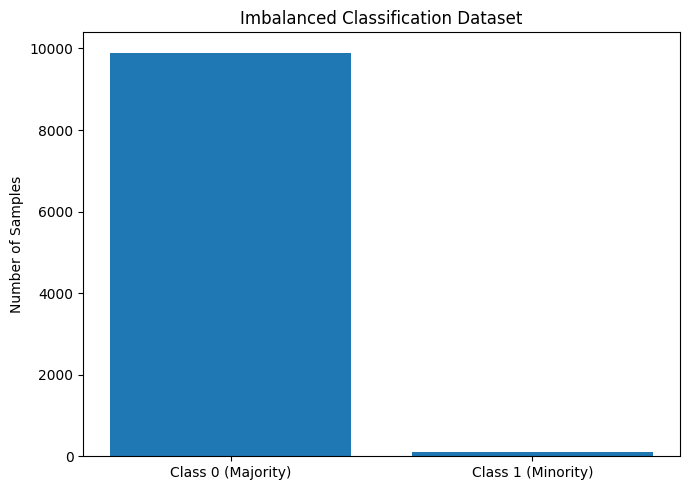

In [3]:
plt.figure(figsize=(7,5))
plt.bar(
    ["Class 0 (Majority)","Class 1 (Minority)"],
    [counts[0],counts[1]]
)
plt.ylabel("Number of Samples")
plt.title("Imbalanced Classification Dataset")
plt.tight_layout()
plt.show()


## 2. A useless model with 99% accuracy

Predict the majority class for everyone.


In [4]:
majority_predictions=np.zeros_like(y)

print("Accuracy:",round(accuracy_score(y,majority_predictions),4))
print("Minority Recall:",round(recall_score(y,majority_predictions,zero_division=0),4))


Accuracy: 0.99
Minority Recall: 0.0


The model can get around **99% accuracy** while detecting **0% of the minority class**.

If Class 1 means fraud, that is operationally useless.


## 3. Train normal Logistic Regression


In [5]:
X_train,X_test,y_train,y_test=train_test_split(
    X,y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

model=LogisticRegression(max_iter=2000)
model.fit(X_train,y_train)

pred=model.predict(X_test)

print(classification_report(
    y_test,
    pred,
    digits=3,
    zero_division=0
))


              precision    recall  f1-score   support

           0      0.991     1.000     0.995      2475
           1      1.000     0.080     0.148        25

    accuracy                          0.991      2500
   macro avg      0.995     0.540     0.572      2500
weighted avg      0.991     0.991     0.987      2500



## 4. Inspect the important metrics


In [6]:
metrics=pd.DataFrame({
    "Metric":[
        "Accuracy",
        "Precision (Minority)",
        "Recall (Minority)",
        "F1 Score (Minority)"
    ],
    "Score":[
        accuracy_score(y_test,pred),
        precision_score(y_test,pred,zero_division=0),
        recall_score(y_test,pred,zero_division=0),
        f1_score(y_test,pred,zero_division=0)
    ]
})

display(metrics.round(3))


,Metric,Score
0,Accuracy,0.991
1,Precision (Minority),1.000
2,Recall (Minority),0.080
3,F1 Score (Minority),0.148


## 5. Confusion Matrix


In [7]:
cm=confusion_matrix(y_test,pred)

display(pd.DataFrame(
    cm,
    index=["Actual 0","Actual 1"],
    columns=["Predicted 0","Predicted 1"]
))


,Predicted 0,Predicted 1
Actual 0,2475,0
Actual 1,23,2


## 6. Add class weights

A simple strategy is:

`class_weight="balanced"`

This tells the model to give more weight to mistakes on the rare class.


In [8]:
weighted_model=LogisticRegression(
    max_iter=2000,
    class_weight="balanced"
)

weighted_model.fit(X_train,y_train)
weighted_pred=weighted_model.predict(X_test)

comparison=pd.DataFrame({
    "Model":[
        "Normal Logistic Regression",
        "Class-Weighted Logistic Regression"
    ],
    "Accuracy":[
        accuracy_score(y_test,pred),
        accuracy_score(y_test,weighted_pred)
    ],
    "Precision":[
        precision_score(y_test,pred,zero_division=0),
        precision_score(y_test,weighted_pred,zero_division=0)
    ],
    "Recall":[
        recall_score(y_test,pred,zero_division=0),
        recall_score(y_test,weighted_pred,zero_division=0)
    ],
    "F1":[
        f1_score(y_test,pred,zero_division=0),
        f1_score(y_test,weighted_pred,zero_division=0)
    ]
})

display(comparison.round(3))


,Model,Accuracy,Precision,Recall,F1
0,Normal Logistic Regression,0.991,1.000,0.08,0.148
1,Class-Weighted Logistic Regression,0.780,0.032,0.72,0.061


## 7. Visual — Accuracy vs Recall


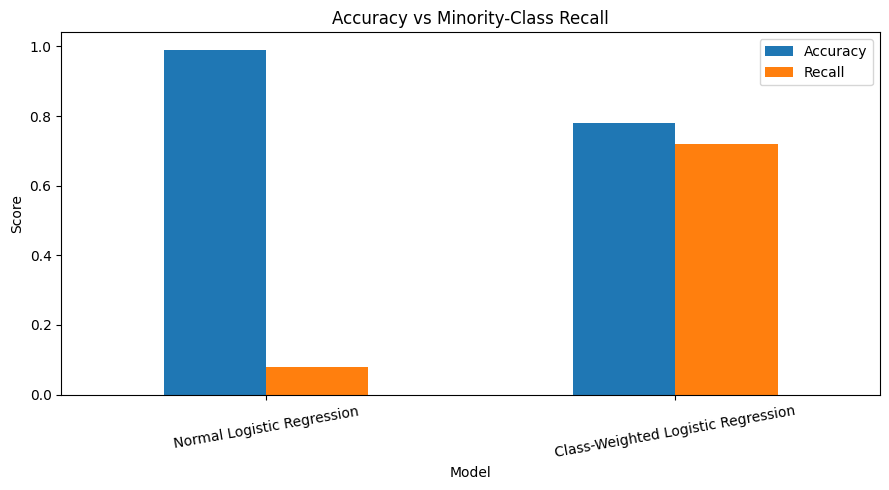

In [9]:
comparison.set_index("Model")[["Accuracy","Recall"]].plot(
    kind="bar",
    figsize=(9,5)
)

plt.ylabel("Score")
plt.title("Accuracy vs Minority-Class Recall")
plt.xticks(rotation=10)
plt.tight_layout()
plt.show()


## Enterprise intuition

Imagine:

- 1,000,000 transactions
- 990,000 genuine
- 10,000 fraud

A model predicting **everything as genuine** gets:

**99% accuracy**

but catches:

**0 fraud**

This is why rare-event problems often focus heavily on Precision, Recall, F1, and PR curves rather than accuracy alone.

Common examples:
- fraud detection
- AML alerts
- cybersecurity intrusion
- equipment failure
- customer churn
- defect detection


## What does this teach?

- Class imbalance can make accuracy misleading.
- A majority-only classifier can have extremely high accuracy.
- Precision and Recall matter when the rare class is important.
- Class weights can improve minority detection.
- Increasing Recall may reduce Precision or overall Accuracy.
- The right metric depends on the business cost of false positives and false negatives.

> **99% accuracy sounds impressive until the model misses 100% of the cases you actually care about.**


## References

- https://scikit-learn.org/stable/modules/model_evaluation.html#classification-metrics
- https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html
- https://scikit-learn.org/stable/modules/generated/sklearn.utils.class_weight.compute_class_weight.html
